#  Early Life Failure Detection

The core assumption is that parts which fail early in the field are statistically distinguishable from healthy parts using end-of-line (EOL) test data, process parameters, or both. The signal tends to be subtle and class imbalance is severe — the vast majority of parts are fine.

Three natural ways to frame the modeling problem:

- Anomaly detection — treat field returns as outliers in EOL feature space, works without labeled failure data
- Binary classification — directly predict which parts will be returned, requires linking field return records to individual serial numbers and their production data
- Survival analysis — most expressive if time-to-failure is available, models not just whether a part fails but when

The business value comes from a few directions. Filtering suspicious parts at the plant reduces the volume going to the failure analysis lab. More strategically, if the model identifies which process parameters correlate with returns — a torque tool, a solder temperature, a supplier batch — the plant can fix the underlying process rather than just react to individual failures.

On evaluation: the relevant metric is not F1 but a cost-weighted one — what does it cost to scrap a good part versus what does it cost when a defective part reaches the field and triggers a warranty return, lab analysis, and a root cause investigation. Framing model performance in those terms with an explicit cost model is exactly the kind of thinking that resonates with manufacturing audiences.

## Scenario: Pressure Sensor Plant — Field Return Analysis

A plant produces manifold absolute pressure (MAP) sensors for automotive OEMs. Each sensor consists of a metal housing, a plastic connector body, an electronic PCB module, and a piezoelectric transducer element. Every finished unit goes through a functional end-of-line test — output signal linearity, offset, sensitivity, response time — and all results are logged against the unit serial number along with traceability data from each assembly station.

After 12–18 months in the field, a warranty return rate above threshold triggers an investigation. The returns lab is overwhelmed. Someone decides to pull the historical EOL and process data for the returned units and compare them against the broader production population.

---

### Variant 1 — The Supplier Batch

Clustering the returned units in the space of EOL features produces a tight cluster. Cross-referencing the traceability data reveals that 80% of the cluster shares the same incoming batch ID for the transducer element — a batch sourced from a specific supplier delivery. The transducer elements passed incoming inspection, but their sensitivity drift under thermal cycling is slightly outside the norm, not enough to fail EOL but enough to degrade over time in the field. The fix is upstream: tighter incoming inspection criteria or a qualification test for that supplier.

### Variant 2 — The Combination of Forces

No single EOL parameter separates the failing units from healthy ones. A feature importance analysis on a trained classifier reveals that it is the interaction between connector insertion force, housing crimp torque, and PCB module seating pressure that predicts returns. Each individually is within spec. Together, at the high end of their respective ranges, they produce cumulative mechanical stress on the transducer bond wires that leads to intermittent failure under vibration in the field. No single process step looks wrong — only the combination flags it.

### Variant 3 — The Substation

Returns span multiple production batches and multiple supplier lots, so Variants 1 and 2 don't apply cleanly. Traceability analysis shows that failing units from different batches, different shifts, and different component lots all share one thing: they were processed on substation 3 of the ultrasonic welding cell, which seals the plastic connector to the metal housing. The weld energy on that substation drifts slightly low during certain ambient temperature conditions, producing a seal that passes leak test at EOL but is marginal enough to allow moisture ingress over months in the field. The substation needs recalibration and a tighter process window.

---

In all three variants, the model doesn't replace the engineering investigation — it dramatically shortens it by pointing at where to look.

## Bosch dataset

Source: https://www.kaggle.com/competitions/bosch-production-line-performance/data

In [94]:
%matplotlib inline

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [96]:
bosch = pd.read_csv('data/train_numeric.csv', nrows=10000)
bosch

,Id,L0_S0_F0,L0_S0_F2,L0_S0_F4,L0_S0_F6,L0_S0_F8,L0_S0_F10,L0_S0_F12,L0_S0_F14,L0_S0_F16,...,L3_S50_F4245,L3_S50_F4247,L3_S50_F4249,L3_S50_F4251,L3_S50_F4253,L3_S51_F4256,L3_S51_F4258,L3_S51_F4260,L3_S51_F4262,Response
0,4,0.030,-0.034,-0.197,-0.179,0.118,0.116,-0.015,-0.032,0.020,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,7,0.088,0.086,0.003,-0.052,0.161,0.025,-0.015,-0.072,-0.225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,9,-0.036,-0.064,0.294,0.330,0.074,0.161,0.022,0.128,-0.026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,11,-0.055,-0.086,0.294,0.330,0.118,0.025,0.030,0.168,-0.169,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,19912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9996,19915,-0.147,-0.168,-0.033,-0.016,0.074,0.161,0.030,0.128,0.056,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9997,19917,-0.095,0.004,0.330,0.312,-0.143,-0.339,0.037,0.128,0.061,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
9998,19921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [97]:
first_col = pd.read_csv('data/train_numeric.csv', usecols=['L0_S0_F0'])
first_col

,L0_S0_F0
0,0.030
1,NaN
2,0.088
3,-0.036
4,-0.055
...,...
1183742,-0.023
1183743,NaN
1183744,0.075
1183745,-0.062


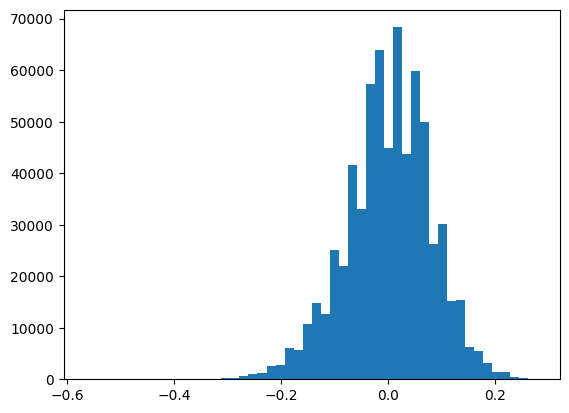

In [98]:
plt.hist(first_col['L0_S0_F0'], bins=50)
plt.show()

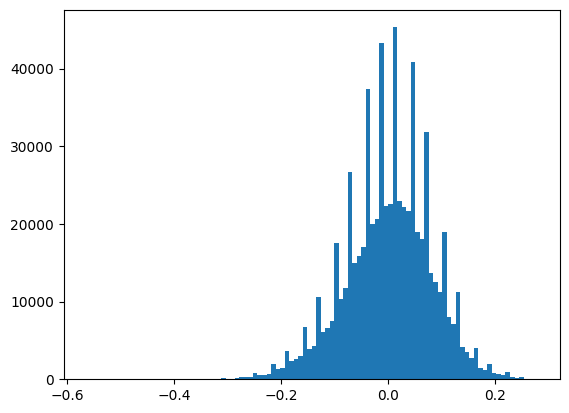

In [99]:
plt.hist(first_col['L0_S0_F0'], bins=100)
plt.show()

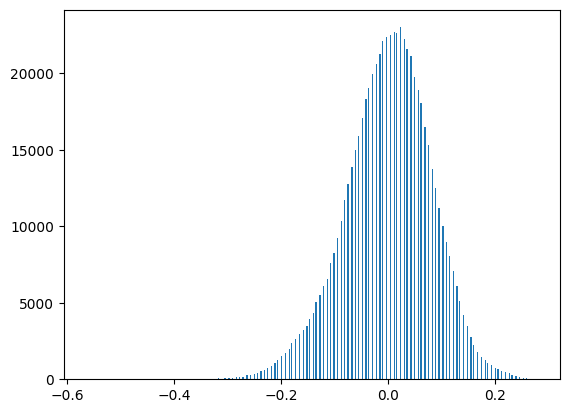

In [100]:
plt.hist(first_col['L0_S0_F0'], bins='fd')
plt.show()

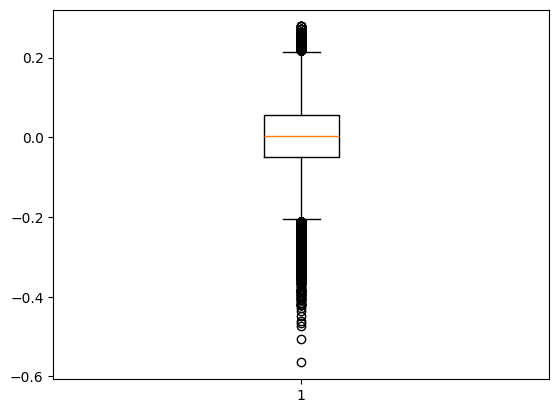

In [101]:
plt.boxplot(first_col['L0_S0_F0'].dropna())
plt.show()


## MCC Intuition

MCC = Matthews Correlation Coefficient

Bosch used MCC because factory quality control has two real costs: releasing a defective part to customers (FN) and scrapping a good part (FP). MCC captures both symmetrically.

In [102]:
import numpy as np
import pandas as pd
from sklearn.metrics import matthews_corrcoef

def evaluate(label, y_true, y_pred):
    y_true, y_pred = list(y_true), list(y_pred)

    tp = sum((t == 1 and p == 1) for t, p in zip(y_true, y_pred))
    tn = sum((t == 0 and p == 0) for t, p in zip(y_true, y_pred))
    fp = sum((t == 0 and p == 1) for t, p in zip(y_true, y_pred))
    fn = sum((t == 1 and p == 0) for t, p in zip(y_true, y_pred))

    total = tp + tn + fp + fn
    accuracy = (tp + tn) / total if total > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    mcc = matthews_corrcoef(y_true, y_pred)

    return {
        "Scenario": label,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "MCC": mcc
    }

rows = []

rows.append(evaluate("Perfect",
    y_true=[0, 0, 0, 1, 1, 1],
    y_pred=[0, 0, 0, 1, 1, 1]))

rows.append(evaluate("Perfectly wrong",
    y_true=[0, 0, 0, 1, 1, 1],
    y_pred=[1, 1, 1, 0, 0, 0]))

rows.append(evaluate("No skill",
    y_true=[0, 0, 1, 1],
    y_pred=[0, 1, 0, 1]))

rows.append(evaluate("All negative (0 TP)",
    y_true=[0, 0, 0, 0, 1, 1],
    y_pred=[0, 0, 0, 0, 0, 0]))

rows.append(evaluate("Bosch naive (all good)",
    y_true=[0]*99 + [1],
    y_pred=[0]*100))

rows.append(evaluate("Catches defect + FPs",
    y_true=[0]*99 + [1],
    y_pred=[0]*95 + [1]*4 + [1]))

df = pd.DataFrame(rows).set_index("Scenario")

# Format float columns for readability
float_cols = ["Accuracy", "Precision", "Recall", "MCC"]
df[float_cols] = df[float_cols].round(3)

print(df.to_string())


                        TP  TN  FP  FN  Accuracy  Precision  Recall    MCC
Scenario                                                                  
Perfect                  3   3   0   0     1.000        1.0     1.0  1.000
Perfectly wrong          0   0   3   3     0.000        0.0     0.0 -1.000
No skill                 1   1   1   1     0.500        0.5     0.5  0.000
All negative (0 TP)      0   4   0   2     0.667        0.0     0.0  0.000
Bosch naive (all good)   0  99   0   1     0.990        0.0     0.0  0.000
Catches defect + FPs     1  95   4   0     0.960        0.2     1.0  0.438


In [103]:
import math

# Dataset: 1M records, 5000 defects (0.5%)


def mcc(tp, fp, fn, tn):
    numerator = (tp * tn) - (fp * fn)

    denominator = math.sqrt(
        (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    )

    return numerator / denominator


# The 5000 defective parts:
TP = 2500    # Found half
FN = 2500    # Missed the other half

# The 995_000 good parts:
FP = 2500    # scrapped good parts (false alarms)
TN = 992_500  # correctly identified as good

mcc(TP, FP, FN, TN)

0.49748743718592964

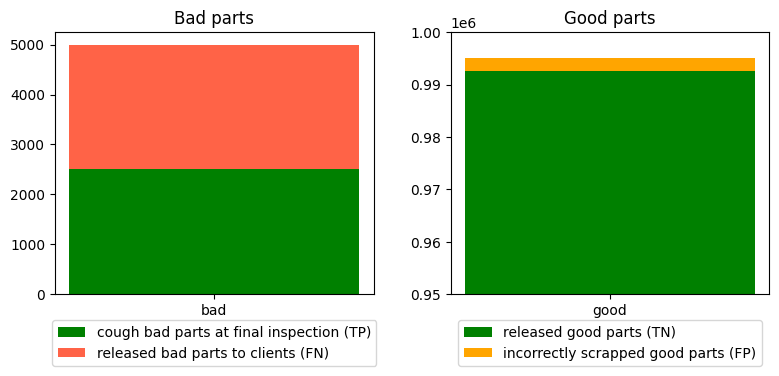

In [104]:
# Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.bar(['bad'], np.array([TP]), color='green', label='cough bad parts at final inspection (TP)')
ax1.bar(['bad'], np.array([FN]), color='tomato', label='released bad parts to clients (FN)', bottom=np.array([TP]))
ax1.set_title('Bad parts')
ax1.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=1)  # Legend below the plot

ax2.bar(['good'], np.array([TN]), color='green', label='released good parts (TN)')
ax2.bar(['good'], np.array([FP]), color='orange', label='incorrectly scrapped good parts (FP)', bottom=np.array([TN]))
ax2.set_title('Good parts')
ax2.set_ylim((0.95e6, 1e6))
ax2.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=1)  # Legend below the plot

# Adjust layout
plt.tight_layout()

# Show the combined figure
plt.show()

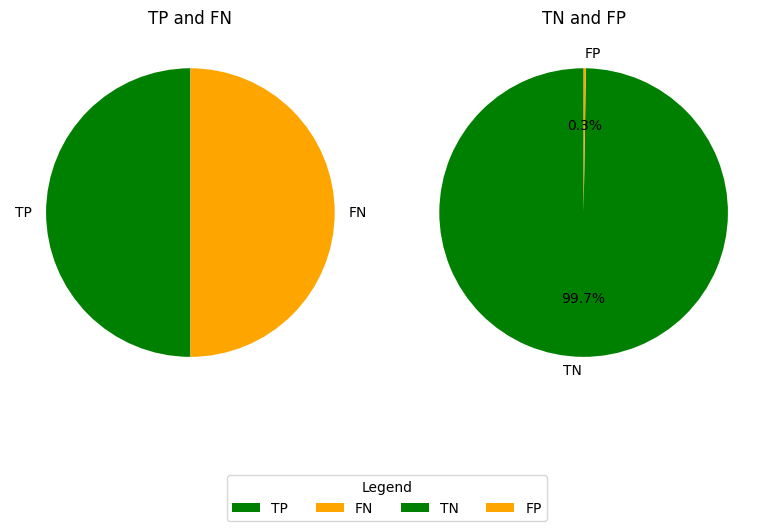

In [105]:
# Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

# First pie chart: TP and FN
labels1 = ['TP', 'FN']
sizes1 = [TP, FN]
colors1 = ['green', 'orange']
ax1.pie(sizes1, labels=labels1, colors=colors1, startangle=90)
ax1.set_title('TP and FN')

# Second pie chart: TN and FP
labels2 = ['TN', 'FP']
sizes2 = [TN, FP]
colors2 = ['green', 'orange']
ax2.pie(sizes2, labels=labels2, colors=colors2, autopct='%1.1f%%', startangle=90)
ax2.set_title('TN and FP')

# Move legend outside
fig.legend(labels1 + labels2, title="Legend", loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=4)

# Adjust layout
plt.tight_layout()

# Show the figure
plt.show()

In [106]:
# The 5000 defective parts:
TP = 3500    # Found most
FN = 1500    # Missed the remaining

# The 995_000 good parts:
FP = 6000    # scrapped more good parts this time
TN = 989_000  # remaining

mcc(TP, FP, FN, TN)

0.5046009945119377

In [107]:
# The 5000 defective parts:
TP = 3500    # Found most
FN = 1500    # Missed the remaining

# The 995_000 good parts:
FP = 95_000    # scrapped LOTS of parts this time
TN = 900_000  # remaining

mcc(TP, FP, FN, TN)

0.1430896141877077

In [108]:
# The 5000 defective parts:
TP = 5000    # Found ALL
FN = 0    # Missed none

# The 995_000 good parts:
FP = 95_000    # again, scrapped LOTS of parts
TN = 900_000  # remaining

mcc(TP, FP, FN, TN)

0.2126643615025008

In [110]:
# The 5000 defective parts:
TP = 5000    # Found ALL
FN = 0    # Missed none

# The 995_000 good parts:
FP = 5000    # scrapped the same amount of good as there are bad
TN = 990_000  # remaining

mcc(TP, FP, FN, TN)

0.7053278933842966

In [115]:
# The 5000 defective parts:
TP = 5000    # Found ALL
FN = 0    # Missed none

# The 995_000 good parts:
FP = 14000    # turns out 14K parts result in 0.5 MMC
TN = 981_000  # remaining

mcc(TP, FP, FN, TN)

0.5093674219949594

In [109]:
# Ideal scenario!

# The 5000 defective parts:
TP = 5000    # Found ALL
FN = 0    # Missed none

# The 995_000 good parts:
FP = 0    # again, scrapped LOTS of parts
TN = 995_000  # remaining

mcc(TP, FP, FN, TN)

1.0